In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


# 1. Import Libraries

In [2]:
# Plotting & Visualization:
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Models
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

# Metrices
from sklearn.metrics import mean_squared_log_error

# 2. Load DataSet

In [3]:
train=pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv',low_memory=False)
test=pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')
sample_sub=pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv')
mdata=pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv')

In [4]:
print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()
train_raw = train.copy()
test_raw = test.copy()

Train shape: (138701, 50)
Test shape : (15000, 49)


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [6]:
test.head()

,TransactionID,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139307,999097,3168,ACH138,GTX,2005,68.0,Low,2007-11-16,521D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139419,1018084,1344,ACH138,GTX,1999,10466.0,Medium,2007-06-01,345BL,...,Steel,None or Unspecified,"15' 9""",None or Unspecified,Yes,Double,NaN,NaN,NaN,NaN
2,1139482,1048712,2808,ACH138,GTX,2001,3817.0,Low,2012-06-16,EX120-5,...,Steel,None or Unspecified,None or Unspecified,Hydraulic,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139522,697537,1089,ACH138,GTX,2006,1498.0,Medium,2010-08-27,304CR,...,Rubber,16 inch,None or Unspecified,Manual,Yes,Double,NaN,NaN,NaN,NaN
4,1139684,1048082,16781,ACH138,GTX,2009,22.0,Low,2010-07-09,L2800D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
mdata.head()

,Variable,Rephrased Description
0,TransactionID,A unique serial number assigned to each indivi...
1,TargetValue,"The financial amount of the transaction, denom..."
2,AssetID,The internal tracking number assigned to a spe...
3,ProductConfigID,A system-generated code representing the techn...
4,DataOriginCode,A code indicating the specific software or pla...


**Descrptive Statistics**

In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,138701.0,2.186276e+06,1.128497e+06,1139309.0,1465754.0,1751884.0,2372139.0,6333410.0
TargetValue,138701.0,4.152187e+04,2.636113e+04,7500.0,20500.0,35000.0,57000.0,142000.0
AssetID,138701.0,1.204814e+06,5.287376e+05,8.0,1007930.0,1246956.0,1495817.0,2478476.0
ProductConfigID,138701.0,7.286422e+03,7.542422e+03,39.0,1693.0,3852.0,11873.0,37209.0
ManufactureYear,138701.0,1.891641e+03,3.069920e+02,1001.0,1990.0,1998.0,2004.0,2015.0
OperationalHoursMeter,82058.0,4.553719e+03,2.792204e+04,0.0,0.0,1620.0,5001.0,1729600.0


### Dummy Model

* Creating a simple dummy model, by predicting the mean target value for all rows.

In [9]:
#x_train = train.drop(columns=['TargetValue'])
#y_train = train["TargetValue"]
#dummy = DummyRegressor(strategy="mean")
#dummy.fit(x_train,y_train)
#preds = dummy.predict(test)
#sample_sub["TargetValue"] = preds
#sample_sub.to_csv("submission.csv",index=False)

# 3. Data Cleaning

Cleaning the dataset before feature engineering and modeling.

This includes:
- Checking duplicates
- Handling missing values
- Fixing the `ManufactureYear = 1001` anomaly
- Parsing `TransactionDate`
- Capping extreme `OperationalHoursMeter` values
- Checking the target column for invalid values

Raw data often contains placeholders, missing values, inconsistent labels, and extreme outliers. Cleaning improves model stability and prevents the model from learning incorrect patterns.


### 3.1 Handle the Duplicates

Checking for fully duplicated rows and fixing duplicated or inconsistent categorical information.

* Fully duplicated rows can cause overfitting.
* Redundant columns add unnecessary noise ( `InventoryGroupDescription` and `InventoryGroupCategory`).
* Inconsistent category names ( "Autoshift" and "AutoShift" ) split the same information into multiple groups, weakening the signal.


In [10]:
print('Fully duplicated rows       :', train.duplicated().sum())
print('Duplicated TransactionID    :', train['TransactionID'].duplicated().sum())
print('Duplicated TransactionID(test):', test['TransactionID'].duplicated().sum())

Fully duplicated rows       : 0
Duplicated TransactionID    : 0
Duplicated TransactionID(test): 0


In [11]:
train[['InventoryGroupDescription','InventoryGroupCategory']].value_counts()

InventoryGroupDescription  InventoryGroupCategory
Track Excavators           TEX                       71018
Motor Graders              MG                        23405
Wheel Loader               WL                        18872
Track Type Tractors        TTT                       14959
Backhoe Loaders            BL                        10381
Skid Steer Loaders         SSL                          66
Name: count, dtype: int64

In [12]:
train['DrivetrainType'].value_counts()

DrivetrainType
None or Unspecified    21482
Standard               20072
Powershift              4700
Hydrostatic             1398
Powershuttle            1006
AutoShift                 41
Autoshift                 32
Direct Drive              14
Name: count, dtype: int64

In [13]:
train = train.drop(columns=["InventoryGroupDescription"])
test  = test.drop(columns=["InventoryGroupDescription"])

for df in [train, test]:
    df["DrivetrainType"] = df["DrivetrainType"].replace({"Autoshift": "AutoShift"})

### 3.2 Handle the missing values

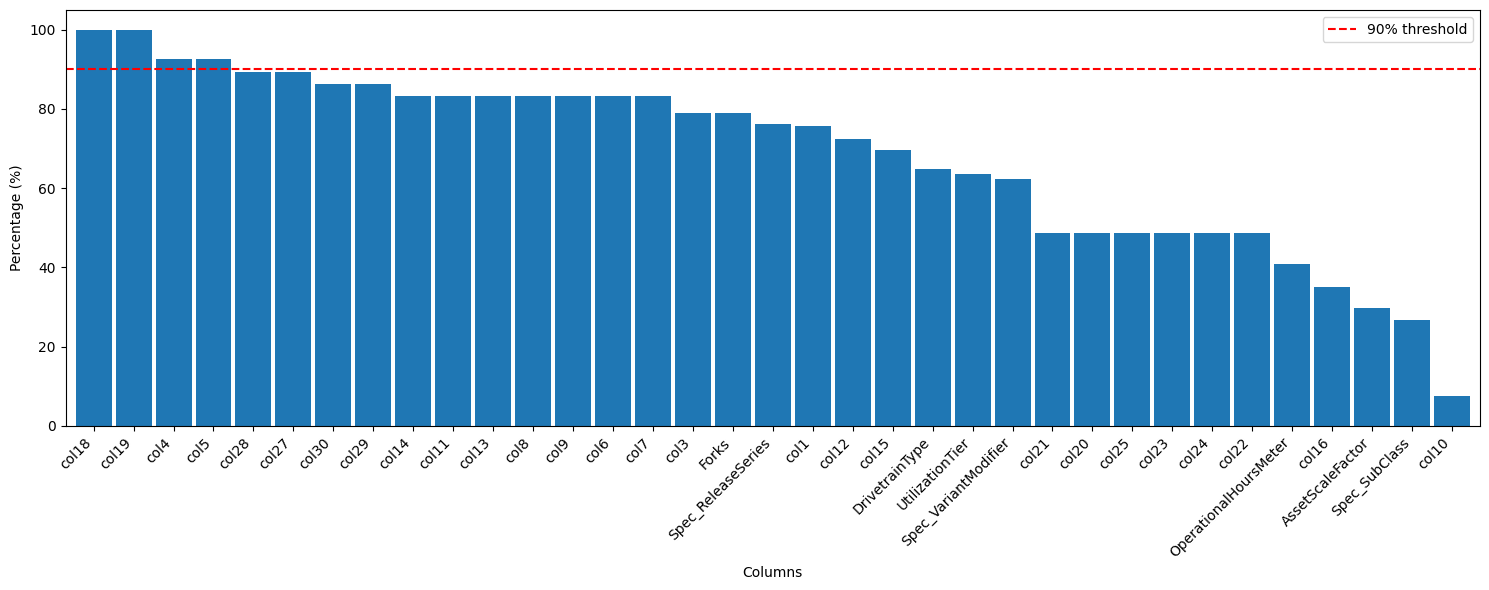

columns exhibit a missing value rate higher than 90% in train


col19    99.952416
col18    99.952416
col5     92.515555
col4     92.515555
dtype: float64

In [14]:
missing_percentage = train.isnull().sum() / len(train) * 100
# filtering out >0
missing_pct = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

# Plot
plt.figure(figsize=(15, 6))
missing_pct.plot(kind="bar",width=0.9)
plt.ylabel("Percentage (%)")
plt.xlabel("Columns")
plt.xticks(rotation=45, ha="right")
plt.axhline(y=90,color='red', linestyle='--', label='90% threshold')
plt.legend()
plt.tight_layout()
plt.show()
print('columns exhibit a missing value rate higher than 90% in train')
missing_percentage[missing_percentage > 90].sort_values(ascending=False)

Columns with extremely high missingness usually contain very little useful information. Keeping them can add noise and slow down training.


In [15]:
train=train.drop(columns=["col18", "col19"]) #'col5', 'col4'])
test=test.drop(columns=["col18", "col19"]) #'col5', 'col4'])
train.shape

(138701, 47)

### 3.3 ManufactureYear Anomaly

<Axes: xlabel='ManufactureYear', ylabel='Count'>

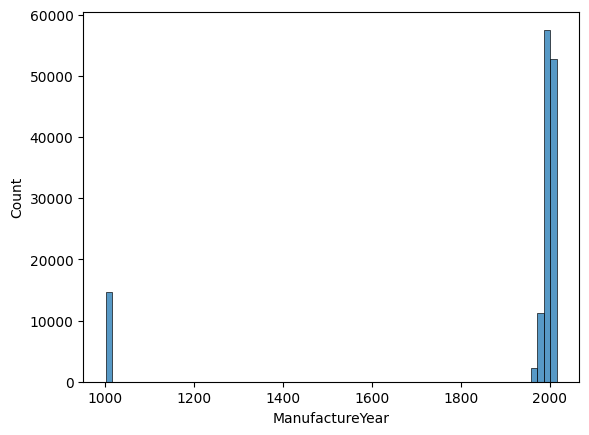

In [16]:
sns.histplot(train['ManufactureYear'], bins=70)

In [17]:
train['ManufactureYear'].unique()

array([1997, 2005, 1994, 2002, 2009, 1001, 1999, 2000, 2004, 1992, 2001,
       2006, 2007, 2003, 1996, 1989, 1993, 1998, 1972, 1979, 1990, 1981,
       1986, 1980, 1977, 2008, 1983, 1995, 1991, 1975, 1988, 1967, 1984,
       1987, 1982, 1971, 1985, 1978, 1976, 1974, 1966, 2010, 2011, 1969,
       1973, 1968, 1965, 1970, 1958, 1959, 1964, 1951, 1949, 1957, 1961,
       1962, 1963, 1920, 1960, 1954, 1921, 1952, 1953, 1955, 2013, 2012,
       2014, 2015])

The value `1001` is clearly not a valid manufacture year.

We Treat it as missing, then recover missing years using related columns such as `ProductConfigID` and `Spec_FullDescriptor`

and after that if there are any missing year, fill it using the median year.

In [18]:
# Treat the anomality as missing
for df in [train, test]:
    df['ManufactureYear'] = df['ManufactureYear'].replace(1001, np.nan)
train['ManufactureYear'].isnull().sum()

np.int64(14719)

In [19]:
# Impute ManufactureYear by ProductConfigID median
year_map = train.groupby('ProductConfigID')['ManufactureYear'].median()

for df in [train, test]:
    df['ManufactureYear'] = df['ManufactureYear'].fillna(
        df['ProductConfigID'].map(year_map))
train['ManufactureYear'].isnull().sum()

np.int64(452)

In [20]:
#Impute by 'Spec_FullDescriptor' median

spec_year_map = train.groupby('Spec_FullDescriptor')['ManufactureYear'].median()

for df in [train,test]:
    df['ManufactureYear'] = df['ManufactureYear'].fillna(
        df['Spec_FullDescriptor'].map(spec_year_map))
train['ManufactureYear'].isnull().sum()

np.int64(423)

In [21]:
# Fill the remaining with median
median_year = train['ManufactureYear'].median()

for df in [train,test]:
    df['ManufactureYear'] = df['ManufactureYear'].fillna(median_year)

train['ManufactureYear'].isnull().sum()

np.int64(0)

### 3.4 Parse TransactionDate

Converting `TransactionDate` into a proper datetime format.

Equipment prices can change over time due to market conditions, inflation, and demand.

So from `TransactionDate` we can extract nw features such as
- sale year
- sale month
- day of week
- time trend

In [22]:
train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])
test['TransactionDate']  = pd.to_datetime(test['TransactionDate'])

### 3.5 OperationalHoursMeter - Winsorise

The maximum recorded value is 1,729,600 hours, equal to 197 years of continuous 24/7 operation
Clearly a data error. We cap the column at the 99th percentile calculated from the training data only.

Also we are creating a missing-value indicator: `hours_missing` and  a zero-hours indicator: `hours_zero`

Then impute missing readings using the median of `ProductConfigID`
and after that if there are any missing readings, fill it using the median reading.

In [23]:
missing_ohm=round((train['OperationalHoursMeter'].isnull().sum()/len(train)*100),2)
ohm_max=train['OperationalHoursMeter'].max()

print('In OperationalHoursMeter',missing_ohm,'% values are missing.')
print(ohm_max,'hours means',round(ohm_max/8760,2),'years of 24/7 operation.\nMeans the data is corrupted. \nCap at the train-derived 99th percentile.')

In OperationalHoursMeter 40.84 % values are missing.
1729600.0 hours means 197.44 years of 24/7 operation.
Means the data is corrupted. 
Cap at the train-derived 99th percentile.


In [24]:
ohm_99=train["OperationalHoursMeter"].quantile(0.99)
print(ohm_99)

25796.00999999995


In [25]:
# Treat zero hours as suspicious/possibly missing
for df in [train, test]:
    df['hours_zero'] = (df['OperationalHoursMeter'] == 0).astype(int)
    df['hours_missing'] = df['OperationalHoursMeter'].isna().astype(int)

# Cap at 99-th percentile

for df in [train, test]:
    df['OperationalHoursMeter'] = df['OperationalHoursMeter'].clip(upper=ohm_99)

In [26]:
# Impute hours by ProductConfigID median

hours_map = train.groupby('ProductConfigID')['OperationalHoursMeter'].median()

train['OperationalHoursMeter'] = train['OperationalHoursMeter'].fillna(
    train['ProductConfigID'].map(hours_map))

test['OperationalHoursMeter'] = test['OperationalHoursMeter'].fillna(
    test['ProductConfigID'].map(hours_map)
)
train['OperationalHoursMeter'].isnull().sum()

np.int64(1276)

In [27]:
# Fill the remaining with median

median_hours = train['OperationalHoursMeter'].median()
train['OperationalHoursMeter'] = train['OperationalHoursMeter'].fillna(median_hours)
test['OperationalHoursMeter'] = test['OperationalHoursMeter'].fillna(median_hours)

### 3.6 Target column Check

Checking the target variable `TargetValue` for missing, negative, or zero values.

RMSLE requires non-negative target values. If negative or zero prices exist, they may need special handling.


In [28]:
print(train['TargetValue'].describe())
print('Negative or zero prices:', (train['TargetValue'] <= 0).sum())
print('Missing target values  :', train['TargetValue'].isna().sum())

count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64
Negative or zero prices: 0
Missing target values  : 0


The `TargetValue` is clean: no missing, negative, or zero prices, so no rows need to be dropped.

# 4. Exploratory Data Analysis

Performing EDA to understand the distribution of the target variable and the relationship between features and price.


### Target Distribution

Plotting the raw `TargetValue` and the transformed `log1p(TargetValue)`.

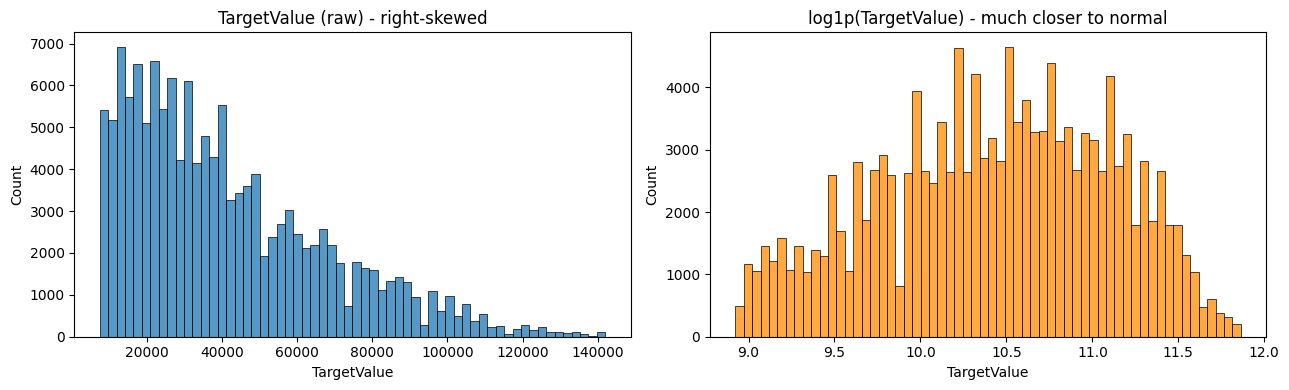

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(train['TargetValue'], bins=60, ax=axes[0])
axes[0].set_title('TargetValue (raw) - right-skewed')
sns.histplot(np.log1p(train['TargetValue']), bins=60, ax=axes[1], color='darkorange')
axes[1].set_title('log1p(TargetValue) - much closer to normal')
plt.tight_layout()
plt.show()

Here the raw `TargetValue` (price) is heavily right-skewed, while `log1p(TargetValue)` is close to a normal shape.

So we are training the model on the  `log1p(TargetValue)` 

### Numeric Feature Distributions

In [30]:
cat = list(train.select_dtypes(include=['object']).columns)
num = list(train.select_dtypes(include='number').columns)

In [31]:
num

['TransactionID',
 'TargetValue',
 'AssetID',
 'ProductConfigID',
 'ManufactureYear',
 'OperationalHoursMeter',
 'hours_zero',
 'hours_missing']

Plotting histograms for key numeric columns such as:
- `OperationalHoursMeter`
- `ProductConfigID`
- `ManufactureYear`
- `AssetID`
 
These plots help detect:
- outliers
- placeholder values
- skewed distributions
- columns that look numeric but are actually categorical IDs

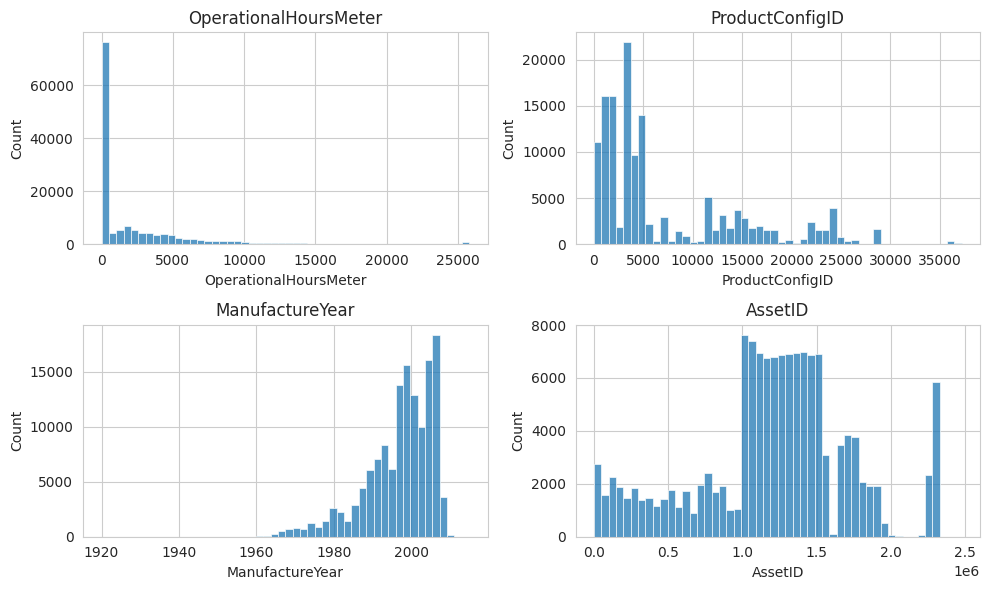

In [32]:
cols_to_plot = ['OperationalHoursMeter', 'ProductConfigID', 'ManufactureYear', 'AssetID']
sns.set_style('whitegrid')

# Create subplots directly with unshared scales
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=False, sharey=False)

# Zip and plot directly
for ax, col in zip(axes.ravel(), cols_to_plot):
    sns.histplot(data=train, x=col, bins=50, ax=ax)
    ax.set_title(col)
    

plt.tight_layout()
plt.show()

**Result:**
- `OperationalHoursMeter` has extreme right skewed.
- `ManufactureYear` is left skewed(most equipments are manufactured after 1990.)
- `ProductConfigID` and `AssetID` are numeric-looking but should be treated as identifiers or categorical features, not continuous numeric values.

### Correlation Heatmap
 
Checking correlations between `TargetValue` and selected numeric columns:
- `ManufactureYear`
- `OperationalHoursMeter`
- `ProductConfigID`


Correlation gives a quick idea of which numeric features have a linear relationship with price.


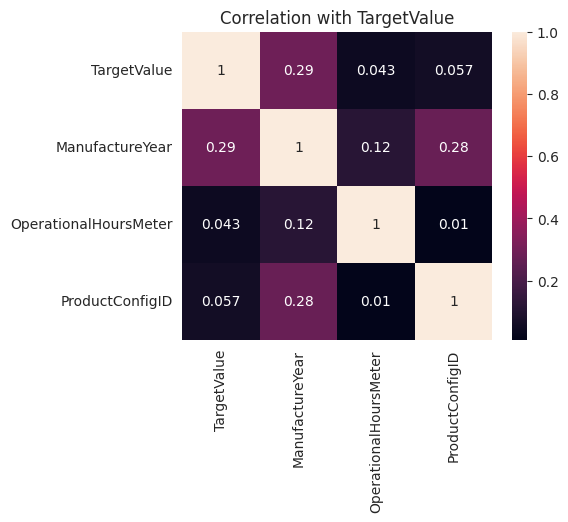

In [33]:
cols = train[['TargetValue', 'ManufactureYear', 'OperationalHoursMeter','ProductConfigID']].copy()
corr = cols.corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True)
plt.title('Correlation with TargetValue')
plt.show()

### Categorical columns

In [34]:
cat

['DataOriginCode',
 'VendorPartnerID',
 'UtilizationTier',
 'Spec_FullDescriptor',
 'Spec_BaseClass',
 'Spec_SubClass',
 'Spec_ReleaseSeries',
 'Spec_VariantModifier',
 'AssetScaleFactor',
 'FunctionalClassification',
 'RegionCode',
 'InventoryGroupCategory',
 'col1',
 'CabinType',
 'Forks',
 'col3',
 'col4',
 'DrivetrainType',
 'col5',
 'col6',
 'col7',
 'col8',
 'col9',
 'col10',
 'col11',
 'col12',
 'col13',
 'col14',
 'col15',
 'col16',
 'col20',
 'col21',
 'col22',
 'col23',
 'col24',
 'col25',
 'col27',
 'col28',
 'col29',
 'col30']

In [35]:
low_cardinality_cols = []
high_cardinality_cols = []

for each in cat :
    if train[each].nunique() <= 10 :
        low_cardinality_cols.append(each)
    else :
        high_cardinality_cols.append(each)

In [36]:
low_cardinality_cols 

['DataOriginCode',
 'UtilizationTier',
 'AssetScaleFactor',
 'InventoryGroupCategory',
 'col1',
 'CabinType',
 'Forks',
 'col3',
 'col4',
 'DrivetrainType',
 'col5',
 'col6',
 'col7',
 'col8',
 'col9',
 'col11',
 'col12',
 'col13',
 'col14',
 'col16',
 'col20',
 'col23',
 'col24',
 'col25',
 'col27',
 'col28',
 'col29',
 'col30']

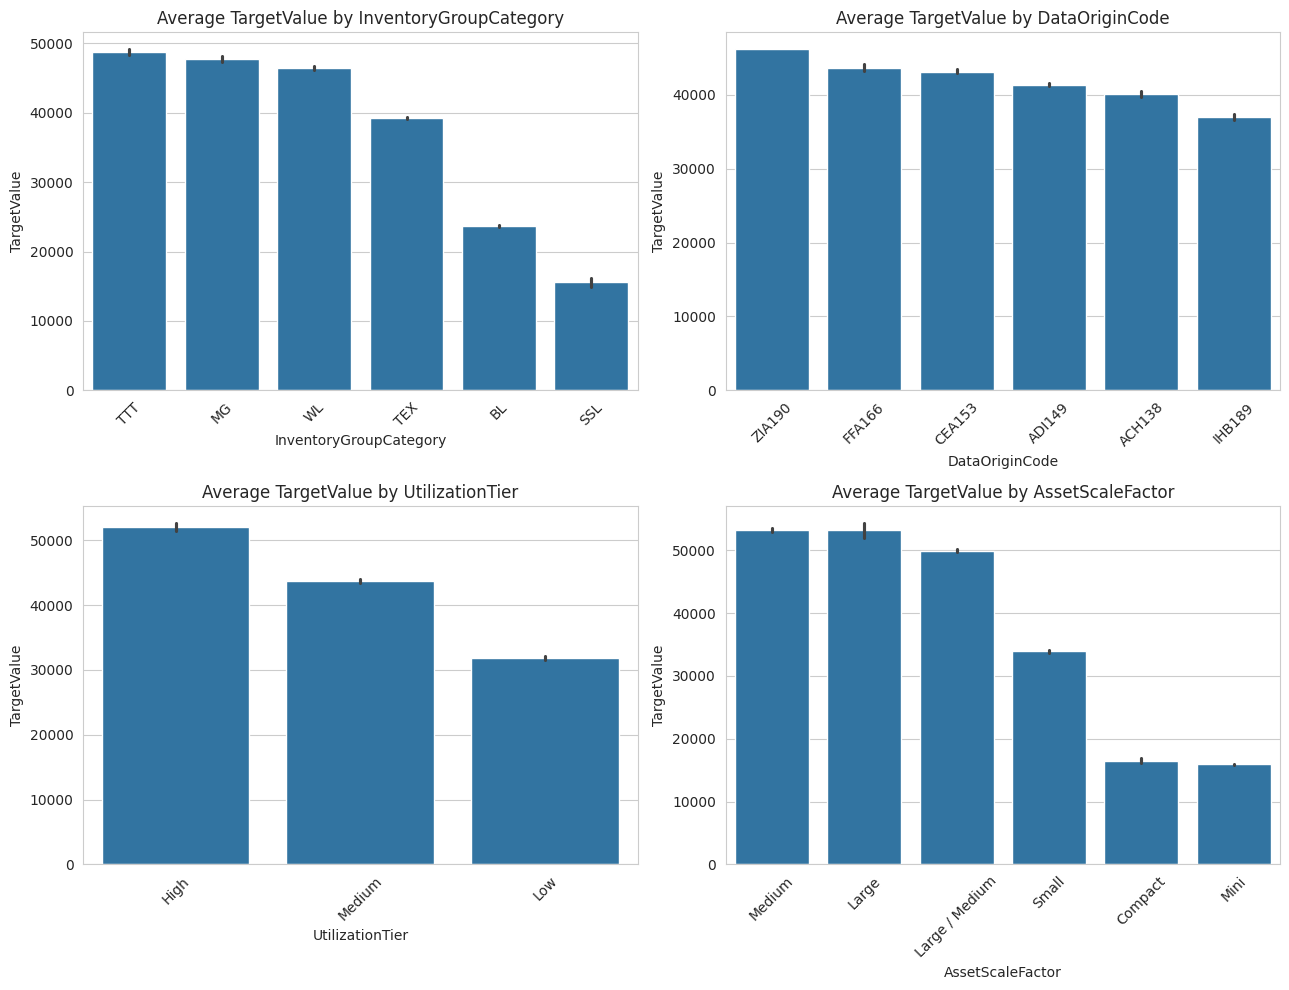

In [37]:
# Average price for the top categories of each of the lower-cardinality columns
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
plot_cols = ['InventoryGroupCategory', 'DataOriginCode', 'UtilizationTier', 'AssetScaleFactor']
for ax, col in zip(axes.ravel(), plot_cols):
    order = train.groupby(col)['TargetValue'].mean().sort_values(ascending=False).index
    sns.barplot(data=train, x=col, y='TargetValue', order=order, ax=ax)
    ax.set_title(f'Average TargetValue by {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Target by FunctionalClassification

plotting average `TargetValue` for the top equipment categories in `FunctionalClassification`.
  
Different types of equipment have very different price ranges. For example, large hydraulic excavators and motor graders may sell for much more than smaller machines.

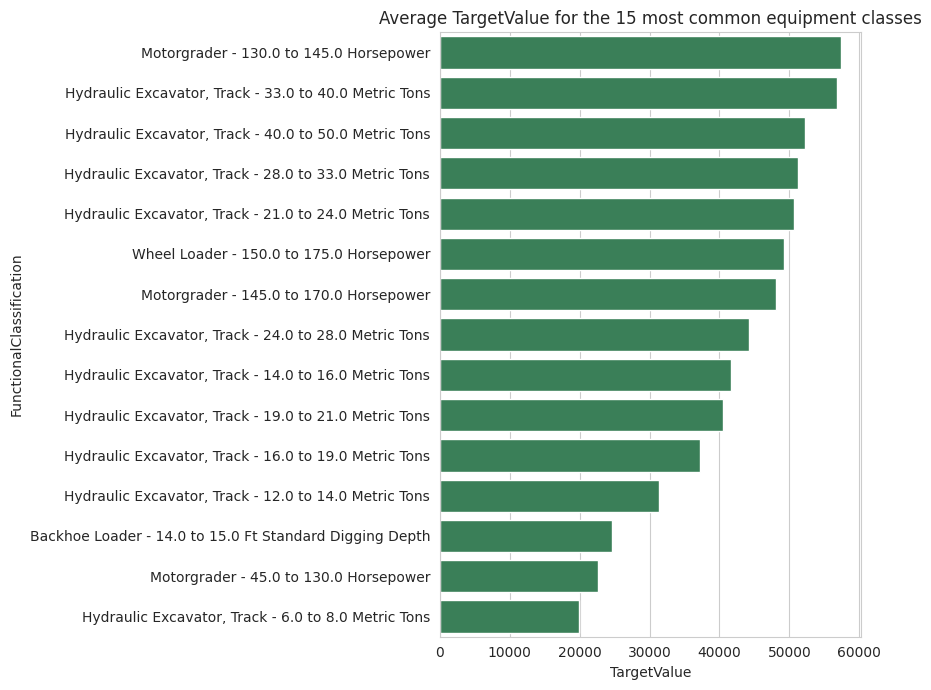

In [38]:
# Equipment category (FunctionalClassification) has 65 levels -- show only the top 15 by volume
top_classes = train['FunctionalClassification'].value_counts().head(15).index
subset = train[train['FunctionalClassification'].isin(top_classes)]

order = subset.groupby('FunctionalClassification')['TargetValue'].mean().sort_values(ascending=False).index
plt.figure(figsize=(9, 7))
sns.barplot(data=subset, y='FunctionalClassification', x='TargetValue', order=order,
            errorbar=None, color='seagreen')
plt.title('Average TargetValue for the 15 most common equipment classes')
plt.tight_layout()
plt.show()

Result :`FunctionalClassification` contains around 65 categories.

The plot shows clear price differences between equipment categories.

This means `FunctionalClassification` is a useful categorical feature for predicting price.

### Average Price by Sale Year

Equipment prices may change over time due to inflation, demand, supply, and market conditions. 

Plots:
* Average `TargetValue` by sale year
* Number of transactions by sale year



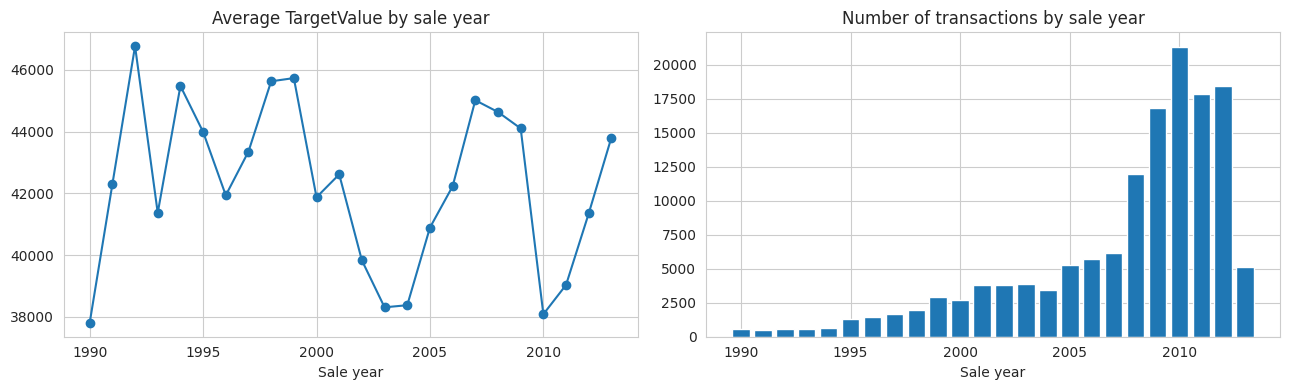

In [39]:
by_year = train.assign(sale_year=(train['TransactionDate']).dt.year).groupby('sale_year')['TargetValue'].agg(['mean', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(by_year.index, by_year['mean'], marker='o')
axes[0].set_title('Average TargetValue by sale year')
axes[0].set_xlabel('Sale year')
axes[1].bar(by_year.index, by_year['count'])
axes[1].set_title('Number of transactions by sale year')
axes[1].set_xlabel('Sale year')
plt.tight_layout()
plt.show()

### Equipment Age vs Sale Price
  
Plotting equipment age at sale against `TargetValue`.

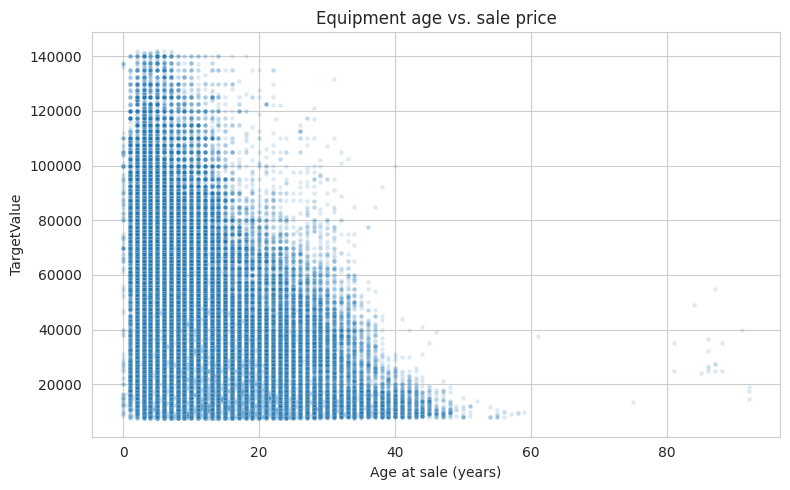

In [40]:
age_preview = ((train['TransactionDate']).dt.year - train['ManufactureYear'])
age_preview = age_preview.where(age_preview >= 0)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=age_preview, y=train['TargetValue'], alpha=0.15, s=10)
plt.xlabel('Age at sale (years)')
plt.ylabel('TargetValue')
plt.title('Equipment age vs. sale price')
plt.tight_layout()
plt.show()

### Target Outlier Check

Checking high-value outliers in `TargetValue` using the IQR method.
Some equipment sales may be very expensive. We need to know whether these are errors or valid high-value transactions.



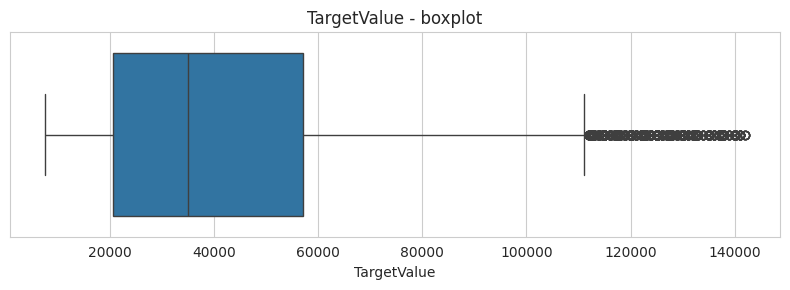

IQR upper fence: 111,750
Rows above upper fence: 1986 (1.4% of train)


In [41]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=train['TargetValue'])
plt.title('TargetValue - boxplot')
plt.tight_layout()
plt.show()

q1, q3 = train['TargetValue'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
print(f'IQR upper fence: {upper_fence:,.0f}')
print(f'Rows above upper fence: {(train['TargetValue'] > upper_fence).sum()} '
      f'({(train['TargetValue'] > upper_fence).mean()*100:.1f}% of train)')

# 5. Feature Engineering

Based on the EDA above, we create new features like 
- date-based features
- machine age features
- usage intensity features
from existig columns.
Creating these features helps the model capture these relationships more directly.


### 5.1 Date-Based Features

Extracting useful information from `TransactionDate`.

Sale timing can affect price. There may be yearly trends, monthly seasonality, or long-term market changes.


In [42]:
for df in [train, test]:
    df['sale_year'] = df['TransactionDate'].dt.year
    df['TransactionQuarter'] = df['TransactionDate'].dt.quarter
    df['sale_month'] = df['TransactionDate'].dt.month
    df['sale_year_month'] = df['sale_year'] * 12 + df['sale_month']
    df['sale_day'] = df['TransactionDate'].dt.day
    df['sale_dow'] = df['TransactionDate'].dt.dayofweek
    df['sale_elapsed'] = (df['TransactionDate'] - pd.Timestamp("1990-01-01")).dt.days
    df['days_since_2000'] = (df['TransactionDate'] - pd.Timestamp('2000-01-01')).dt.days

### 5.2 Machine Age at Sale

Machine age is one of the most important factors affecting equipment price. Older machines usually have lower value.

In [43]:
for df in [train, test]:
    df['age_at_sale'] = df['sale_year'] - df['ManufactureYear']
    df.loc[df['age_at_sale'] < 0, 'age_at_sale'] = np.nan

### 5.3 Usage intensity

Operational hours represent how much the machine has been used. Higher usage usually means more wear and lower resale value.

The log transformation reduces the effect of extreme hour values.


In [44]:
for df in [train, test]:
    df['log_hours'] = np.log1p(df['OperationalHoursMeter'])

Here we have extracted everything from `TransactionDate`. So we ca drop it

In [45]:
train_fe = train.drop(columns=['TransactionDate'])
test_fe = test.drop(columns=['TransactionDate'])

### Check Correlation of New Features with Price

This helps to confirm that whether the engineered features are useful before feeding them into the model.


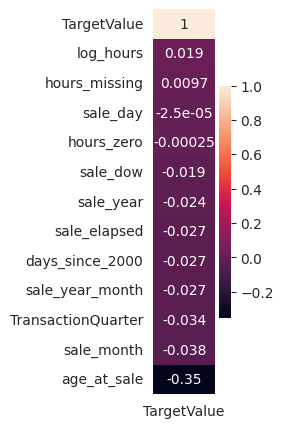

In [46]:
new_features = ['sale_year','TransactionQuarter', 'sale_month', 'sale_year_month', 'sale_day', 'sale_dow', 'sale_elapsed', 'days_since_2000', 'age_at_sale', 'log_hours', 'hours_zero', 'hours_missing']
correlation_data = (train[new_features + ['TargetValue']]).corr()

plt.figure(figsize=(1, 5))
sns.heatmap(correlation_data[['TargetValue']].sort_values(by='TargetValue', ascending=False), annot=True)#, fmt=".4f")
plt.show()

Here we can see that Features such as `age_at_sale`, `log_hours`, and time-based features show meaningful relationships with the target.
( As the machine age and usage hour increases selling price is falling down)

This confirms that the feature engineering step is adding usefull informations.

# 6. Preprocessing and Pipelines

Preparing the data for modeling.

Steps:
- Separate numeric and categorical columns
- Create feature matrix `X`
- Create log-transformed target `y`
- Create test feature matrix `X_test`
- Build preprocessing pipelines
- Transform train, validation, and test data

**Why I am doing it:**  
Models require numeric input. Numeric features need imputation, while categorical features need encoding.

The target is log-transformed because RMSLE is a log-based metric.

In [47]:
# Define Target, ID, Numeric and Categorical Columns
TARGET = 'TargetValue'
ID_COL = 'TransactionID'

CAT_COLS = [c for c in train_fe.columns
            if (train_fe[c].dtype == 'object' or str(train_fe[c].dtype) == 'str')]
NUM_COLS = [c for c in train_fe.columns if c not in CAT_COLS + [TARGET, ID_COL]]

print(len(NUM_COLS), 'numeric columns and', len(CAT_COLS), 'categorical columns')


16 numeric columns and 40 categorical columns


In [48]:
#Creatng X,y and Train-Test Split
X = train_fe.drop(columns=[TARGET])
y = np.log1p(train_fe[TARGET])   # log-target -> squared error in log space == RMSLE
X_test = test_fe

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.15, random_state=42)


Building a preprocessing pipeline using `ColumnTransformer`.

Machine learning models require numeric input. Preprocessing ensures that missing values and categorical labels are handled consistently across train, validation, and test data.

Numeric features:
- imputed using median

Categorical features:
- imputed using a constant missing label
- encoded into numeric form


In [49]:
numeric_transformer = SimpleImputer(strategy='median')
categorical_transformer = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUM_COLS),
    ('cat', categorical_transformer, CAT_COLS),
])

X_tr_enc = preprocessor.fit_transform(X_tr[NUM_COLS + CAT_COLS])
X_val_enc = preprocessor.transform(X_val[NUM_COLS + CAT_COLS])
X_test_enc = preprocessor.transform(X_test[NUM_COLS + CAT_COLS])

CAT_FEATURE_IDX = list(range(len(NUM_COLS), len(NUM_COLS) + len(CAT_COLS)))

print('Encoded train shape:', X_tr_enc.shape)
print('Any missing values left in encoded train?', np.isnan(X_tr_enc).any())

Encoded train shape: (117895, 56)
Any missing values left in encoded train? False


### RMSLE Evaluation Function

The competition metric is RMSLE (Root Mean Squared Logarithmic Error) , so we need a local evaluation function that matches the leaderboard metric as closely as possible.


In [50]:
def rmsle(y_true_log, y_pred_log):
    y_true_raw = np.expm1(y_true_log)
    y_pred_raw = np.expm1(y_pred_log)
    y_pred_raw = np.clip(y_pred_raw, 0, None)
    return np.sqrt(mean_squared_log_error(y_true_raw, y_pred_raw))

# 7. Native Models

Training three baseline models:
- **LightGBM** - fast and strong on tabular data.
- **XGBoost** - robust and generalizes well.
- **CatBoost** - especially good with categorical features.

### 7.1 LightGBM

In [51]:

native_lgb = lgb.LGBMRegressor(random_state=42, verbosity=-1)
native_lgb.fit(X_tr_enc, y_tr, categorical_feature=CAT_FEATURE_IDX)
pred_native_lgb = native_lgb.predict(X_val_enc)
rmsle_native_lgb = rmsle(y_val, pred_native_lgb)
print(f'Native LightGBM RMSLE: {rmsle_native_lgb:.4f}')

Native LightGBM RMSLE: 0.2158


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 7.2 XGBoost


In [52]:
native_xgb = XGBRegressor(random_state=42, n_jobs=-1)
native_xgb.fit(X_tr_enc, y_tr)
pred_native_xgb = native_xgb.predict(X_val_enc)
rmsle_native_xgb = rmsle(y_val, pred_native_xgb)
print(f'Native XGBoost RMSLE: {rmsle_native_xgb:.4f}')

Native XGBoost RMSLE: 0.2242


### 7.3 CatBoost

In [53]:
native_cat = CatBoostRegressor(random_state=42, verbose=False)
native_cat.fit(X_tr_enc, y_tr)
pred_native_cat = native_cat.predict(X_val_enc)
rmsle_native_cat = rmsle(y_val, pred_native_cat)
print(f'Native CatBoost RMSLE: {rmsle_native_cat:.4f}')

Native CatBoost RMSLE: 0.2185


### Native Model Comparison

Comparing the validation RMSLE of the three baseline models.
The model with the lowest validation RMSLE is selected for further tuning.

In [54]:
results = pd.DataFrame({
    'model': ['LightGBM', 'XGBoost', 'CatBoost'],
    'rmsle': [rmsle_native_lgb, rmsle_native_xgb, rmsle_native_cat]}).sort_values('rmsle')
results

,model,rmsle
0,LightGBM,0.215792
2,CatBoost,0.218480
1,XGBoost,0.224246


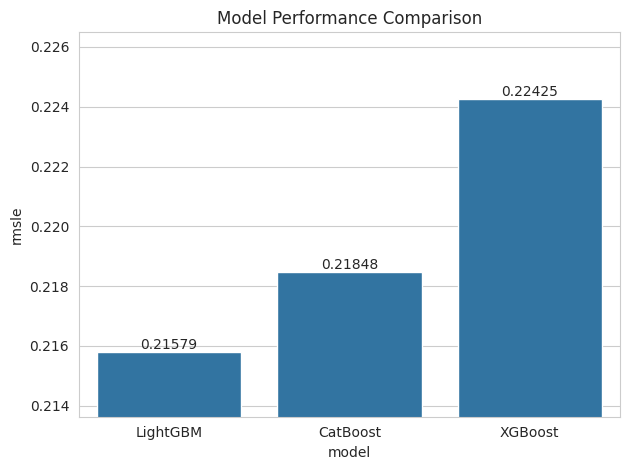

In [55]:
ax = sns.barplot(x='model', y='rmsle', data=results)

# 2. Add text labels on top of the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.5f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

ymin = results['rmsle'].min() * 0.99  # 1% below the lowest score
ymax = results['rmsle'].max() * 1.01  # 1% above the highest score
plt.ylim(ymin, ymax)

# Labels and title
plt.title('Model Performance Comparison')

plt.tight_layout()
plt.show()


# 8. Tuning

Tuning LightGBM using a small set of hyperparameter candidates.
Default or baseline hyperparameters may not give the best possible score. Tuning helps the model generalize better and reduce validation RMSLE.

Hyperparameters being tested include:
- **learning_rate** - Controls the step size at each boosting iteration. Smaller values improve accuracy but require more trees.
- **num_leaves** - Sets the maximum number of nodes in a tree.
- **min_child_samples** - Defines the minimum number of data points needed in a leaf node
- **subsample** - Dictates the fraction of rows randomly selected to train each individual tree.
- **colsample_bytree** - Specifies the fraction of columns randomly chosen for each tree.

Early stopping is used to avoid overfitting.


In [56]:
param_candidates = [
    {'learning_rate': 0.05, 'num_leaves': 127, 'min_child_samples': 30, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'learning_rate': 0.03, 'num_leaves': 255, 'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8},
]

tuning_results = []  #compare the result
tuned_models = []   #created to store tuned model objects to use later

for i, params in enumerate(param_candidates):
    m = lgb.LGBMRegressor(
        n_estimators=4000,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
        **params,
    )
    m.fit(
        X_tr_enc, y_tr,
        eval_set=[(X_val_enc, y_val)],
        categorical_feature=CAT_FEATURE_IDX,
        callbacks=[lgb.early_stopping(80, verbose=False)],
    )
    pred = m.predict(X_val_enc, num_iteration=m.best_iteration_)
    score = rmsle(y_val, pred)
    tuning_results.append({**params, 'best_iteration': m.best_iteration_, 'rmsle': score})
    tuned_models.append(m)
    print(f'Candidate {i}: RMSLE={score:.4f}, best_iteration={m.best_iteration_}, params={params}')

tuning_results_df = pd.DataFrame(tuning_results).sort_values('rmsle').reset_index(drop=True)
tuning_results_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Candidate 0: RMSLE=0.1971, best_iteration=2472, params={'learning_rate': 0.05, 'num_leaves': 127, 'min_child_samples': 30, 'subsample': 0.8, 'colsample_bytree': 0.8}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Candidate 1: RMSLE=0.1944, best_iteration=2890, params={'learning_rate': 0.03, 'num_leaves': 255, 'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8}


,learning_rate,num_leaves,min_child_samples,subsample,colsample_bytree,best_iteration,rmsle
0,0.03,255,20,0.8,0.8,2890,0.194385
1,0.05,127,30,0.8,0.8,2472,0.197083


Selecting the tuned LightGBM model with the lowest validation RMSLE.
It is used as the main component of the final prediction.

In [57]:
best_candidate_idx = int(np.argmin([r['rmsle'] for r in tuning_results]))
tuned_model = tuned_models[best_candidate_idx]
pred_tuned = tuned_model.predict(X_val_enc, num_iteration=tuned_model.best_iteration_)
rmsle_tuned = rmsle(y_val, pred_tuned)

print('Best hyperparameters:', param_candidates[best_candidate_idx])
print(f'Tuned LightGBM validation RMSLE: {rmsle_tuned:.4f}')
print(f'(Native/untuned LightGBM was     : {rmsle_native_lgb:.4f})')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Best hyperparameters: {'learning_rate': 0.03, 'num_leaves': 255, 'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8}
Tuned LightGBM validation RMSLE: 0.1944
(Native/untuned LightGBM was     : 0.2158)


# 9. Blending Predictions

Individual models can make different types of errors. Blending reduces variance and often improves leaderboard stability.

So,here blending predictions from:
- tuned LightGBM
- native XGBoost
- native CatBoost

In [58]:
blend_candidates = []
for w_lgb in [1.0, 0.9, 0.8, 0.7, 0.6]:
    w_other = 1 - w_lgb
    blended_pred = (w_lgb * pred_tuned
                     + (w_other / 2) * pred_native_xgb
                     + (w_other / 2) * pred_native_cat)
    score = rmsle(y_val, blended_pred)
    blend_candidates.append({'lgb_weight': w_lgb, 'xgb_weight': w_other/2,
                              'cat_weight': w_other/2, 'rmsle': score})

blend_df = pd.DataFrame(blend_candidates).sort_values('rmsle').reset_index(drop=True)
blend_df

,lgb_weight,xgb_weight,cat_weight,rmsle
0,0.8,0.10,0.10,0.193068
1,0.9,0.05,0.05,0.193334
2,0.7,0.15,0.15,0.193589
3,1.0,0.00,0.00,0.194385
4,0.6,0.20,0.20,0.194892


In [59]:
best_blend = blend_df.iloc[0]
use_blend = best_blend['rmsle'] < rmsle_tuned

print(f'Best blend RMSLE        : {best_blend["rmsle"]:.4f} '
      f'(LGB={best_blend["lgb_weight"]:.2f}, XGB={best_blend["xgb_weight"]:.2f}, CAT={best_blend["cat_weight"]:.2f})')
print(f'Tuned LightGBM alone    : {rmsle_tuned:.4f}')
print(f'Use the blend for the final model? {use_blend}')

Best blend RMSLE        : 0.1931 (LGB=0.80, XGB=0.10, CAT=0.10)
Tuned LightGBM alone    : 0.1944
Use the blend for the final model? True


# 10. Final Prediction and Submission
Refitting on the full training data uses all available information. Converting back from log space returns predictions to the original price scale.
Steps:
1. Refit the preprocessing pipeline on the full training data
2. Train the final model or models on all training data
3. Predict on the test set
4. Convert predictions back from log space using `expm1`
5. Clip predictions to be non-negative

In [60]:
# refit the preprocessor + all needed models on 100% of the training data
X_all_enc = preprocessor.fit_transform(X[NUM_COLS + CAT_COLS])
X_test_enc_final = preprocessor.transform(X_test[NUM_COLS + CAT_COLS])
y_all = y

best_lgb_params = param_candidates[best_candidate_idx]
final_lgb = lgb.LGBMRegressor(
    n_estimators=tuned_model.best_iteration_,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    **best_lgb_params,
)
final_lgb.fit(X_all_enc, y_all, categorical_feature=CAT_FEATURE_IDX)
test_pred_lgb = final_lgb.predict(X_test_enc_final)

if use_blend:
    final_xgb = XGBRegressor(random_state=42, n_jobs=-1)
    final_xgb.fit(X_all_enc, y_all)
    test_pred_xgb = final_xgb.predict(X_test_enc_final)

    final_cat = CatBoostRegressor(random_state=42, verbose=False)
    final_cat.fit(X_all_enc, y_all)
    test_pred_cat = final_cat.predict(X_test_enc_final)

    w_lgb, w_xgb, w_cat = best_blend['lgb_weight'], best_blend['xgb_weight'], best_blend['cat_weight']
    test_pred_log = w_lgb * test_pred_lgb + w_xgb * test_pred_xgb + w_cat * test_pred_cat
    print(f'Using BLEND for final predictions (LGB={w_lgb:.2f}, XGB={w_xgb:.2f}, CAT={w_cat:.2f})')
else:
    test_pred_log = test_pred_lgb
    print('Using tuned LightGBM ALONE for final predictions')

test_pred = np.clip(np.expm1(test_pred_log), 0, None)
test_pred[:10]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Using BLEND for final predictions (LGB=0.80, XGB=0.10, CAT=0.10)


array([67485.67408892, 79547.99187891, 31466.98495004, 20046.69523586,
       12784.6429734 , 26861.92396483, 18898.05885397, 46510.94725796,
       71627.42545389, 16009.14518402])

In [61]:
# remove any existing submission file
!rm submission.csv 

rm: cannot remove 'submission.csv': No such file or directory


In [62]:
sample_sub['TargetValue'] = test_pred
sample_sub.to_csv('submission.csv', index=False)
sample_sub.head()

,TransactionID,TargetValue
0,1139307,67485.674089
1,1139419,79547.991879
2,1139482,31466.984950
3,1139522,20046.695236
4,1139684,12784.642973


# Milestones

In [63]:
# Milestone 1 Verification

# 1. Dataset dimensions
print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)
print()

# 2. Target variable by difference
target_column = list(set(train_raw.columns) - set(test_raw.columns))
print("Target column identified by set difference:", target_column)
print()

# 3. Numeric columns count by default dtypes
numeric_cols = train_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Number of numeric columns:", len(numeric_cols))
print("Numeric columns:", numeric_cols)
print()

# 4. Columns with missing rate greater than 90%
missing_pct = train_raw.isnull().mean() * 100
sparse_cols = missing_pct[missing_pct > 90].sort_values(ascending=False)
print("Columns with more than 90% missing values:")
print(sparse_cols)
print()

# 5. Missing percentage of OperationalHoursMeter
ohm_missing_pct = train_raw['OperationalHoursMeter'].isnull().mean() * 100
print("OperationalHoursMeter missing percentage:", round(ohm_missing_pct, 2))
print()

# 6. TargetValue summary
print("TargetValue summary:")
print(train_raw['TargetValue'].describe())
print()

# 7. ManufactureYear anomaly / mode
print("ManufactureYear anomaly:", train_raw['ManufactureYear'].mode()[0])
print(train_raw['ManufactureYear'].value_counts().head(10))
print()

# 8. TransactionDate range
transaction_dates = pd.to_datetime(train_raw['TransactionDate'], errors='coerce')
print("Earliest TransactionDate:", transaction_dates.min())
print("Latest TransactionDate:", transaction_dates.max())
print()

# 9. Spec_BaseClass cardinality
print("Spec_BaseClass unique values:", train_raw['Spec_BaseClass'].nunique())
print()

# 10. RegionCode volume
print("Top RegionCode by transaction volume:")
print(train_raw['RegionCode'].value_counts().head(10))
print()

# 11. Average TargetValue for Florida
florida_avg_price = train_raw.loc[train_raw['RegionCode'] == 'Florida', 'TargetValue'].mean()
print("Average TargetValue for Florida:", round(florida_avg_price, 2))
print()

# 12. UtilizationTier distribution
print("UtilizationTier value counts including missing:")
print(train_raw['UtilizationTier'].value_counts(dropna=False))
print()

# 13. Pearson correlation between TargetValue and OperationalHoursMeter
corr_price_hours = train_raw[['TargetValue', 'OperationalHoursMeter']].corr().iloc[0, 1]
print("Pearson correlation between TargetValue and OperationalHoursMeter:", round(corr_price_hours, 4))
print()

# 14. Most common FunctionalClassification
print("Top FunctionalClassification values:")
print(train_raw['FunctionalClassification'].value_counts().head(10))

Train shape: (138701, 50)
Test shape: (15000, 49)

Target column identified by set difference: ['TargetValue']

Number of numeric columns: 6
Numeric columns: ['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID', 'ManufactureYear', 'OperationalHoursMeter']

Columns with more than 90% missing values:
col19    99.952416
col18    99.952416
col5     92.515555
col4     92.515555
dtype: float64

OperationalHoursMeter missing percentage: 40.84

TargetValue summary:
count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64

ManufactureYear anomaly: 1001
ManufactureYear
1001    14719
2006    10895
2005     9564
1999     7243
2007     7133
1998     6447
1997     6151
2000     6096
2004     6019
2001     5764
Name: count, dtype: int64

Earliest TransactionDate: 1990-01-31 00:00:00
Latest TransactionDate: 2013-04-28 00:00:00

Spec_B

In [64]:
# Milestone 2 

# Use raw train copy so the milestone calculations are independent
m2 = train_raw.copy()

# Parse date
m2['TransactionDate'] = pd.to_datetime(m2['TransactionDate'])

# features required
m2['TransactionYear'] = m2['TransactionDate'].dt.year
m2['TransactionQuarter'] = m2['TransactionDate'].dt.quarter
m2['AssetAge'] = m2['TransactionYear'] - m2['ManufactureYear']
m2['DescriptorLength'] = m2['Spec_FullDescriptor'].astype(str).apply(len)
m2['HasOperationalHours'] = m2['OperationalHoursMeter'].notna().astype(int)
m2['HasVariantModifier'] = m2['Spec_VariantModifier'].notna().astype(int)

# Q1 most frequent AssetAge
print("Most frequent AssetAge:")
print(m2['AssetAge'].mode(dropna=False).iloc[0])

# Q2 quarter with highest average TargetValue
quarter_avg = m2.groupby('TransactionQuarter')['TargetValue'].mean()
print("\nAverage TargetValue by TransactionQuarter:")
print(quarter_avg)
print("\nQuarter with highest average TargetValue:", quarter_avg.idxmax())

# Q3 maximum DescriptorLength
print("\nMaximum DescriptorLength:", m2['DescriptorLength'].max())

# Q4 records with HasOperationalHours = 1
print("\nRecords with HasOperationalHours = 1:", m2['HasOperationalHours'].sum())

# Q5 percentage with variant information
variant_pct = m2['HasVariantModifier'].mean() * 100
print("\nPercentage of records with variant information:", round(variant_pct, 2))

# Q6 mean ManufactureYear
print("\nMean ManufactureYear:", round(m2['ManufactureYear'].mean(), 2))

Most frequent AssetAge:
5

Average TargetValue by TransactionQuarter:
TransactionQuarter
1    42873.587453
2    41408.258228
3    40619.200589
4    40562.454024
Name: TargetValue, dtype: float64

Quarter with highest average TargetValue: 1

Maximum DescriptorLength: 19

Records with HasOperationalHours = 1: 82058

Percentage of records with variant information: 37.73

Mean ManufactureYear: 1891.64


In [65]:
# Milestone 3 Verification

m3 = train_raw.copy()

# Datetime extraction
m3['TransactionDate'] = pd.to_datetime(m3['TransactionDate'], errors='coerce')
m3['SaleYear'] = m3['TransactionDate'].dt.year

print("Most frequent SaleYear:", m3['SaleYear'].mode()[0])

# Remove ManufactureYear anomalies: 1000 and 1001
m3['ManufactureYear'] = m3['ManufactureYear'].replace([1000, 1001], np.nan)

# AssetAge
m3['AssetAge'] = m3['SaleYear'] - m3['ManufactureYear']
print("Median AssetAge after removing 1000/1001:", m3['AssetAge'].median())

# HoursPerYear
m3['HoursPerYear'] = m3['OperationalHoursMeter'] / m3['AssetAge']
m3['HoursPerYear'] = m3['HoursPerYear'].replace([np.inf, -np.inf], np.nan)

print("Median HoursPerYear:", round(m3['HoursPerYear'].median(), 2))

# Columns missing more than 80%
missing_raw_pct = train_raw.isnull().mean() * 100
cols_missing_above_80 = missing_raw_pct[missing_raw_pct > 80]
print("\nNumber of columns missing more than 80%:", len(cols_missing_above_80))
print(cols_missing_above_80.sort_values(ascending=False))

# CabinType missing count if filled with "Missing"
cabin_missing_count = train_raw['CabinType'].isnull().sum()
print("\nRows that would become 'Missing' in CabinType:", cabin_missing_count)

# Train-test split verification
X_m3 = train_raw.drop(columns=['TargetValue'])
y_m3 = train_raw['TargetValue']

X_train_m3, X_test_m3, y_train_m3, y_test_m3 = train_test_split(
    X_m3,
    y_m3,
    test_size=0.2,
    random_state=42
)

print("\nX_train rows:", X_train_m3.shape[0])
print("X_test rows:", X_test_m3.shape[0])

# Ordinal encoding of UtilizationTier
utilization = train_raw['UtilizationTier'].fillna('Unspecified').astype(str)
ordinal_encoder = OrdinalEncoder()
utilization_encoded = ordinal_encoder.fit_transform(utilization.values.reshape(-1, 1))

print("\nUnique encoded UtilizationTier values:", len(np.unique(utilization_encoded)))

# Log-transformed target standard deviation
log_target = np.log1p(train_raw['TargetValue'])
print("\nStandard deviation of log1p(TargetValue):", round(log_target.std(), 4))

Most frequent SaleYear: 2010
Median AssetAge after removing 1000/1001: 8.0
Median HoursPerYear: 320.0

Number of columns missing more than 80%: 15
col19    99.952416
col18    99.952416
col4     92.515555
col5     92.515555
col28    89.214930
col27    89.214930
col29    86.393753
col30    86.393753
col11    83.125572
col8     83.125572
col7     83.125572
col6     83.125572
col9     83.125572
col13    83.125572
col14    83.125572
dtype: float64

Rows that would become 'Missing' in CabinType: 0

X_train rows: 110960
X_test rows: 27741

Unique encoded UtilizationTier values: 4

Standard deviation of log1p(TargetValue): 0.671


In [66]:
# Milestone 4 Verification

from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error

# Use only the columns specified in Milestone 4
m4 = train_raw[[
    'TargetValue',
    'UtilizationTier',
    'DrivetrainType',
    'CabinType',
    'AssetScaleFactor',
    'ManufactureYear',
    'OperationalHoursMeter'
]].copy()

# Fill missing UtilizationTier with Unknown
m4['UtilizationTier'] = m4['UtilizationTier'].fillna('Unknown')

# Create 5 quantile-based price bands
m4['PriceBand'] = pd.qcut(m4['TargetValue'], q=5, labels=False)

X_m4 = m4.drop(columns=['TargetValue'])
y_m4 = m4['TargetValue']

# ------------------------------------------------------------
# Q1: Stratified vs Non-Stratified Split
# ------------------------------------------------------------

# A) Stratified split
X_train_s, X_valid_s, y_train_s, y_valid_s = train_test_split(
    X_m4,
    y_m4,
    test_size=0.3,
    random_state=42,
    stratify=m4['PriceBand']
)

valid_counts_stratified = (
    X_valid_s['PriceBand']
    .value_counts()
    .reindex(range(5), fill_value=0)
    .sort_index()
    .to_numpy()
)

# B) Non-stratified split
X_train_n, X_valid_n, y_train_n, y_valid_n = train_test_split(
    X_m4,
    y_m4,
    test_size=0.3,
    random_state=42,
    stratify=None
)

valid_counts_non_stratified = (
    X_valid_n['PriceBand']
    .value_counts()
    .reindex(range(5), fill_value=0)
    .sort_index()
    .to_numpy()
)

# C) Maximum absolute difference in validation proportions
prop_stratified = valid_counts_stratified / valid_counts_stratified.sum()
prop_non_stratified = valid_counts_non_stratified / valid_counts_non_stratified.sum()

max_abs_diff = np.abs(prop_stratified - prop_non_stratified).max()

print("Stratified validation counts:", valid_counts_stratified)
print("Non-stratified validation counts:", valid_counts_non_stratified)
print("Maximum absolute proportion difference:", round(max_abs_diff, 4))

Stratified validation counts: [8651 8410 8000 8374 8176]
Non-stratified validation counts: [8732 8271 8123 8412 8073]
Maximum absolute proportion difference: 0.0033


In [67]:
# Q2: Preprocessing Pipeline

cat_cols_m4 = ['UtilizationTier', 'DrivetrainType', 'CabinType', 'AssetScaleFactor']
num_cols_m4 = ['ManufactureYear', 'OperationalHoursMeter']

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor_m4 = ColumnTransformer(transformers=[
    ('cat', categorical_pipeline, cat_cols_m4),
    ('num', numerical_pipeline, num_cols_m4)
], remainder='drop')

X_train_proc = preprocessor_m4.fit_transform(X_train_s)
X_valid_proc = preprocessor_m4.transform(X_valid_s)

# Convert sparse matrices to dense arrays for later models
if hasattr(X_train_proc, 'toarray'):
    X_train_proc = X_train_proc.toarray()
    X_valid_proc = X_valid_proc.toarray()

print("X_train_proc shape:", X_train_proc.shape)
print("X_valid_proc shape:", X_valid_proc.shape)
print("Sum of all values in X_train_proc:", round(float(X_train_proc.sum()), 3))

X_train_proc shape: (97090, 23)
X_valid_proc shape: (41611, 23)
Sum of all values in X_train_proc: 388360.0


# Final Summary

**Main insights from EDA:**
- The target variable is right-skewed, so log transformation is appropriate.
- Equipment age is negatively correlated with price.
- Operational hours and usage intensity are useful predictors.
- Equipment category and configuration contain strong price information.
- High-value outliers exist but are mostly valid expensive sales.

**Main modeling decisions:**
- Train using `log1p(TargetValue)` to align with RMSLE.
- Use gradient boosting models: LightGBM, XGBoost, and CatBoost.
- Tune the strongest model.
- Blend predictions only if validation RMSLE improves.

**Expected outcome:**
A more stable and improved RMSLE score, moving from the current `0.1926` region toward the target `0.1900` region.